In [1]:
import warnings

warnings.filterwarnings("ignore")

In [2]:
def new_iterative_nonlinear_inversion(
    data_up,
    bounding_boxes,
    height_difference=5.0,
    copy_data=True,
):
    locations_ = []
    dipole_moments_ = []
    r2_values = []

    table = vd.grid_to_table(data_up)
    global_coordinates = (table.x.values, table.y.values, table.z.values)
    shape = data_up.shape
    data_updated = data_up.copy(deep=True) if copy_data else data_up

    for box in bounding_boxes:
        anomaly = data_updated.sel(x=slice(*box[:2]), y=slice(*box[2:]))

        dx, dy, dz, tga = mg.gradient(anomaly)
        anomaly["dx"], anomaly["dy"], anomaly["dz"], anomaly["tga"] = dx, dy, dz, tga

        table = vd.grid_to_table(anomaly)

        euler = hm.EulerDeconvolution(3)
        euler.fit((table.x, table.y, table.z), (table.bz, table.dx, table.dy, table.dz))

        bz_corrected = table.bz.values - euler.base_level_
        coordinates = (table.x.values, table.y.values, table.z.values)

        model_nl = mg.NonlinearMagneticDipoleBz(
            initial_location=euler.location_, max_iter=1000
        )
        model_nl.fit(coordinates, bz_corrected)

        locations_.append(model_nl.location_)
        dipole_moments_.append(model_nl.dipole_moment_)
        r2_values.append(model_nl.r2_)

        modeled_bz = mg.dipole_bz(
            global_coordinates, model_nl.location_, model_nl.dipole_moment_
        )
        modeled_bz = np.reshape(modeled_bz, shape)

        data_updated.values -= modeled_bz
        dx, dy, dz, tga = mg.gradient(data_updated)
        data_updated["dx"] = dx
        data_updated["dy"] = dy
        data_updated["dz"] = dz
        data_updated["tga"] = tga

    return data_updated, locations_, dipole_moments_, r2_values

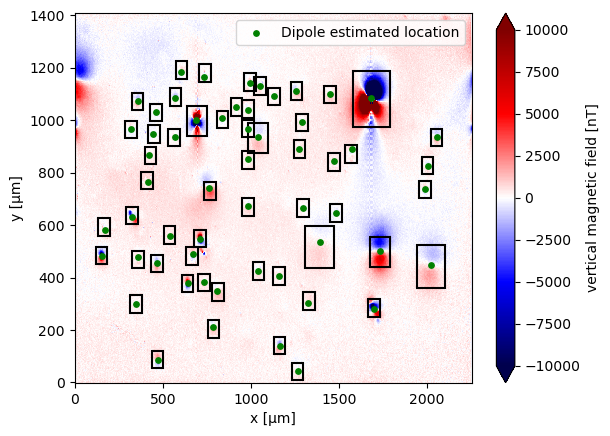

In [3]:
import ensaio
import harmonica as hm
import matplotlib.pyplot as plt
import numpy as np
import skimage.exposure
import verde as vd
import xarray as xr

import magali as mg

fname = ensaio.fetch_morroco_speleothem_qdm(version=1, file_format="matlab")
data = mg.read_qdm_harvard(fname)

height_difference = 5.0

data_up = (
    hm.upward_continuation(data, height_difference)
    .assign_attrs(data.attrs)
    .assign_coords(x=data.x, y=data.y)
    .assign_coords(z=data.z + height_difference)
    .rename("bz")
)

dx, dy, dz, tga = mg.gradient(data_up)
data_up["dx"], data_up["dy"], data_up["dz"], data_up["tga"] = dx, dy, dz, tga

stretched = skimage.exposure.rescale_intensity(
    tga, in_range=tuple(np.percentile(tga, (1, 99)))
)
data_tga_stretched = xr.DataArray(stretched, coords=data_up.coords)

bounding_boxes = mg.detect_anomalies(
    data_tga_stretched,
    size_range=[20, 150],
    detection_threshold=0.02,
    border_exclusion=2,
)

data_updated, locations_, dipole_moments_, r2_values = (
    new_iterative_nonlinear_inversion(
        data_up,
        bounding_boxes,
        height_difference=height_difference,
        copy_data=True,
    )
)

fig, ax = plt.subplots()
data.plot.pcolormesh(ax=ax, cmap="seismic", vmin=-10000, vmax=10000)
mg.plot_bounding_boxes(bounding_boxes, ax=ax, color="black", linewidth=1.5)
locations_arr = np.array(locations_)
ax.scatter(
    locations_arr[:, 0],  # x
    locations_arr[:, 1],  # y
    c="green",
    marker=".",
    s=60,
    label="Dipole estimated location",
)
plt.legend()
plt.show()

In [4]:
moments = np.array(dipole_moments_)


mx = moments[:, 0]
my = moments[:, 1]
mz = moments[:, 2]

In [5]:
np.shape(dipole_moments_)  # [0]
r2_values

[np.float64(0.8887574906799602),
 np.float64(0.923170968750696),
 np.float64(0.9961369624596157),
 np.float64(0.8419150014584726),
 np.float64(0.9877720064570689),
 np.float64(0.9979099404237142),
 np.float64(0.9992816503256304),
 np.float64(0.8003172383381367),
 np.float64(0.9867503768200041),
 np.float64(0.9935143946619424),
 np.float64(0.9977724205522334),
 np.float64(0.9857435375406458),
 np.float64(0.9971177614758588),
 np.float64(0.9901262387753296),
 np.float64(0.9745274365566954),
 np.float64(0.9627043966587632),
 np.float64(0.991447083552177),
 np.float64(0.988135251450542),
 np.float64(0.9190811065066947),
 np.float64(0.89111648857703),
 np.float64(0.9986433744271005),
 np.float64(0.9630727084349117),
 np.float64(0.9780013813892803),
 np.float64(0.9930208945065789),
 np.float64(0.886893280444381),
 np.float64(0.8582978451614752),
 np.float64(0.21936621822051106),
 np.float64(0.9526082818188115),
 np.float64(0.9194223473406258),
 np.float64(0.9174427048986608),
 np.float64(0.9

In [6]:
def vector_to_angles(vector):
    """
    Generate inclination, declination, and amplitude from a 3-component vector

    Inclination is positive downwards and declination is the angle with the y
    component. The vector has x, y, and z (upward) Cartesian components.

    Parameters
    ----------
    vector : 1D or 2D array
        The x, y, z vector components. Can be a 1D array for a single vector
        or 2D for multiple. If 2D, then each vector should be a row of the
        array.

    Returns
    -------
    inclination : float or array
        The inclination values in degrees.
    declination : float or array
        The declination values in degrees.
    amplitude : float or array
        The vector amplitude values.
    """
    vector = np.asarray(vector)
    x, y, z = vector.T
    amplitude = np.sqrt(x**2 + y**2 + z**2)
    inclination = -np.degrees(np.arctan2(z, np.hypot(x, y)))
    declination = np.degrees(np.arctan2(x, y))
    return inclination, declination, amplitude


def plot_stereonet(
    dipole_moments,
    ax=None,
    cmap="plasma",
    cmap_norm=plt.Normalize,
    vmin=None,
    vmax=None,
    label="",
    add_ticks=True,
    **kwargs,
):
    """
    Plot the dipole moments in a stereonet.

    The moment magnitude is set as the color.
    Positive inclination symbols are solid, negative are just the outline.
    """
    if ax is None:
        fig = plt.figure()
        ax = fig.add_subplot(1, 1, 1, projection="stereonet")

    ax.set_facecolor("#eeeeee")  # color "#eeeeee"
    ax.grid(linestyle="-", color="#cccccc", linewidth=1)
    ax.set_longitude_grid_ends(90)
    if add_ticks:
        # Add ticks manually because mplstereonet doesn't work with subplots
        ax.set_azimuth_ticks([])
        ax.text(0.2, 1.65, "0°")
        ax.text(0.2, -1.8, "180°")
        ax.text(-2, -0.025, "270°")
        ax.text(1.65, -0.025, "90°")

    if label and not label.endswith(" "):
        label = label + " "

    inclination, declination, amplitude = vector_to_angles(dipole_moments)

    # Generate colors based on the amplitude values
    norm = cmap_norm(vmin=vmin, vmax=vmax)
    colors = plt.colormaps[cmap](norm(amplitude))

    positive_inc = inclination > 0
    ax.scatter(
        *mplstereonet.line(inclination[positive_inc], declination[positive_inc]),
        c=colors[positive_inc],
        label=f"{label}$I > 0$",
        edgecolors="#333333",
        **kwargs,
    )
    ax.scatter(
        *mplstereonet.line(-inclination[~positive_inc], declination[~positive_inc]),
        c="#ffffff00",
        label=f"{label}$I \le 0$",
        edgecolors=colors[~positive_inc],
        **kwargs,
    )

    mappable = plt.cm.ScalarMappable(norm, cmap=cmap)
    return mappable


def equal_area_projection(vectors):
    # norm = np.linalg.norm(vectors, axis=1)
    # vectors_unitary = vectors / norm[:, np.newaxis]
    vectors = np.asarray(vectors)
    vectors_unitary = np.empty_like(vectors)
    for i in range(vectors.shape[0]):
        vector = vectors[i]
        norm = np.sqrt(np.sum(vector**2))
        vectors_unitary[i] = vector / norm
    inclinations, declinations, amplitudes = vector_to_angles(vectors)

    # XY_projected = np.zeros((len(vectors), 3))
    XY_projected = np.empty_like(vectors)
    for i, projected_vector in enumerate(vectors_unitary):
        r = np.sqrt(1 - np.abs(vectors_unitary[i, 2])) / np.sqrt(
            vectors_unitary[i, 0] ** 2 + vectors_unitary[i, 1] ** 2
        )
        XY_projected[i, 0] = r * vectors_unitary[i, 1]
        XY_projected[i, 1] = r * vectors_unitary[i, 0]
        XY_projected[i, 2] = amplitudes[i] if inclinations[i] >= 0 else -amplitudes[i]

    return XY_projected


class StereographicProjection:
    def __init__(self, vectors):
        self.vectors = vectors

    def plot(
        self,
        ax=None,
        cmap="inferno",
        cmap_norm=plt.Normalize,
        vmin=None,
        vmax=None,
        label="",
        # s=50,
        add_ticks=True,
        draw_cross=True,
        add_radial_grid=True,
        facecolor="#ffffff00",
        add_legend=False,
        **kwargs,
    ):
        """
        Draw the stereographic projection
        """
        if ax is None:
            fig = plt.figure()
            ax = fig.add_subplot(1, 1, 1)

        # Add a face color
        background_circle = plt.Circle((0, 0), 1, color=facecolor, zorder=-2)
        ax.add_artist(background_circle)

        # Draw the great circle
        circle = plt.Circle((0, 0), 1, color="black", fill=False, zorder=3)
        ax.add_artist(circle)

        # Define the clipping area
        clip_path = plt.Circle((0, 0), 1, transform=ax.transData)

        if add_ticks:
            # Add ticks
            ax.text(-0.025, 1.05, "0°")
            ax.text(-0.05, -1.075, "180°")
            ax.text(-1.15, -0.025, "270°")
            ax.text(1.025, -0.025, "90°")

        if label and not label.endswith(" "):
            label = label + " "
            # Draw the central cross if requested
            if draw_cross:
                hline = ax.axhline(y=0, color="black", zorder=-1)
                hline.set_clip_path(clip_path)
                vline = ax.axvline(x=0, color="black", zorder=-1)
                vline.set_clip_path(clip_path)

        # Draw the radial grid
        if add_radial_grid:
            for rad_dec in range(0, 360, 10):  # Grid lines every 10 degrees
                rad_inc = np.linspace(0, 90, 1000)  # Inclinations from 0 to 90 degrees
                # rad_int = np.ones_like(rad_inc)  # Constant amplitude for the grid lines

                # Generate the radial vectors
                radial_vector = angles_to_vector(rad_inc, rad_dec, 1)

                # Project the radial vectors
                radial_projected = equal_area_projection(radial_vector)

                # Plot each radial grid line
                ax.plot(
                    radial_projected[:, 1],
                    radial_projected[:, 0],
                    color="gray",
                    zorder=-2,
                    lw=0.5,
                )
            for circ_inc in range(0, 90, 10):
                circ_dec = np.linspace(
                    0, 360, 1000
                )  # Inclinations from 0 to 90 degrees
                circ_int = np.ones_like(
                    circ_dec
                )  # Constant amplitude for the grid lines

                # Generate the radial vectors
                circle_vector = angles_to_vector(circ_inc, circ_dec, circ_int)
                # Project the radial vectors
                circle_projected = equal_area_projection(circle_vector)

                # Plot each radial grid line
                ax.plot(
                    circle_projected[:, 1],
                    circle_projected[:, 0],
                    color="gray",
                    zorder=-2,
                    lw=0.5,
                )

        # Calculate the equal area projection
        XY_projected = equal_area_projection(self.vectors)

        # Generate colors based on the amplitude values
        norm = cmap_norm(vmin=vmin, vmax=vmax)
        colors = plt.colormaps[cmap](norm(abs(XY_projected[:, 2])))

        # Plotting the data
        positive_inc = XY_projected[:, 2] > 0
        scatter_pos = ax.scatter(
            XY_projected[:, 1][positive_inc],
            XY_projected[:, 0][positive_inc],
            c=colors[positive_inc],
            edgecolors="#ffffff00",
            label=f"{label}$I > 0$",
            **kwargs,
        )
        scatter_pos.set_clip_path(clip_path)

        scatter_neg = ax.scatter(
            XY_projected[:, 1][~positive_inc],
            XY_projected[:, 0][~positive_inc],
            c="#ffffff00",
            edgecolors=colors[~positive_inc],
            label=rf"{label}$I \leq 0$",
            **kwargs,
        )
        scatter_neg.set_clip_path(clip_path)

        # Configure the axis
        ax.set_aspect("equal")
        ax.set_xticks([])
        ax.set_yticks([])
        if add_legend:
            ax.legend()
        for spine in ax.spines.values():
            spine.set_visible(False)

        # Colormap (if necessary)
        mappable = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
        return mappable

In [7]:
def angles_to_vector(inclination, declination, amplitude):
    """
    Generate a 3-component vector from inclination, declination, and amplitude

    Inclination is positive downwards and declination is the angle with the y
    component. The vector has x, y, and z (upward) Cartesian components.

    Parameters
    ----------
    inclination : float or array
        The inclination values in degrees.
    declination : float or array
        The declination values in degrees.
    amplitude : float or array
        The vector amplitude values.

    Returns
    -------
    vector : 1D or 2D array
        The calculated x, y, z vector components. 1D if it's a single vector.
        If N vectors are calculated, the "vector" will have shape (N, 3) with
        each vector in a row of the array.
    """
    inclination = np.radians(inclination)
    declination = np.radians(declination)
    amplitude = np.asarray(amplitude)
    sin_inc = np.sin(-inclination)
    cos_inc = np.cos(-inclination)
    sin_dec = np.sin(declination)
    cos_dec = np.cos(declination)
    x = cos_inc * sin_dec * amplitude
    y = cos_inc * cos_dec * amplitude
    z = sin_inc * amplitude
    return np.transpose([x, y, z])

In [8]:
inclinations, declinations, amplitudes = vector_to_angles(dipole_moments_)

In [9]:
declinations

array([-151.26077192,    6.76326116, -174.58057875,  157.14038853,
        -17.93165744,   -2.06059226,  178.23918418,  141.84085234,
       -173.24962293,  169.63823279,   -4.59636107, -176.00839818,
       -169.07343196, -175.28075169,  149.89826905, -178.91237299,
        163.42009642,    5.61520294,  169.83212672, -159.04658693,
       -168.02112981, -152.61601411,  174.80165614, -172.4581858 ,
        -12.66620214, -171.4765229 ,  -54.04637733, -171.6279681 ,
        151.86823565,  178.79453969,   -9.5952296 ,   49.55439615,
         -0.3332225 , -173.44520754,  165.45345541,  -43.65329618,
        167.35357632,  162.05117781,   41.76513221,  167.78236638,
        -96.57297351,   54.66799907,   37.85822777, -150.22290065,
          6.59881751,   -1.60906986,   13.38404612, -172.86266835,
        163.97725295,   63.51480321, -144.07299856,  149.03103015,
       -166.54343052,  172.83867419,  142.8218514 ,  156.72341396,
         22.74955854])

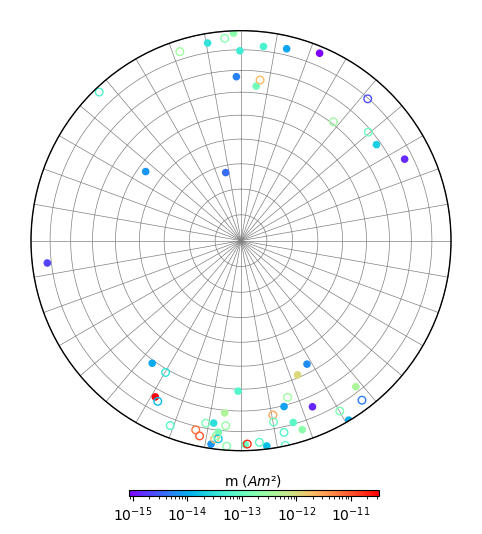

In [10]:
projection = StereographicProjection(dipole_moments_)

import matplotlib.patches

cmap = "rainbow"  # Escolha um colormap
cmap_norm = matplotlib.colors.LogNorm  # Normalize
maximum = np.max([len(inclinations)])
kwargs = dict(s=30, cmap=cmap, cmap_norm=cmap_norm)

fig, ax = plt.subplots(figsize=(10, 6))
tmp = projection.plot(ax=ax, add_ticks=False, **kwargs)

clb = fig.colorbar(
    tmp,
    ax=ax,
    # cax=fig.add_axes([0.5, 0.3, 0.25, 0.01]),
    cax=fig.add_axes([0.4, 0.07, 0.25, 0.01]),
    # format="%.0g",
    orientation="horizontal",
)
clb.set_label(label=r"m ($Am²$)", fontsize=10, labelpad=-37, loc="center")
clb.ax.tick_params(labelsize=10)

In [11]:
window = bounding_boxes[12]

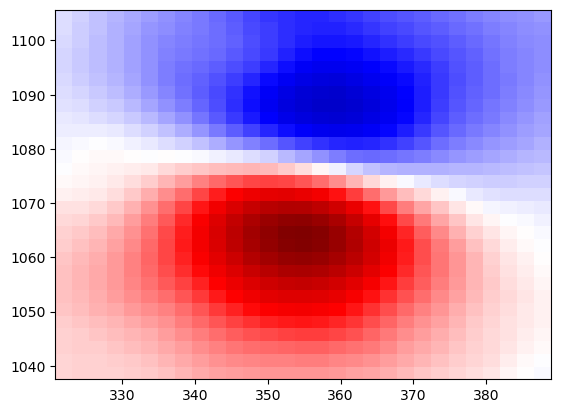

In [12]:
local_data = data_up.sel(x=slice(*window[:2]), y=slice(*window[2:]))
local_data.plot.pcolormesh(cmap="seismic", add_colorbar=False, add_labels=False)

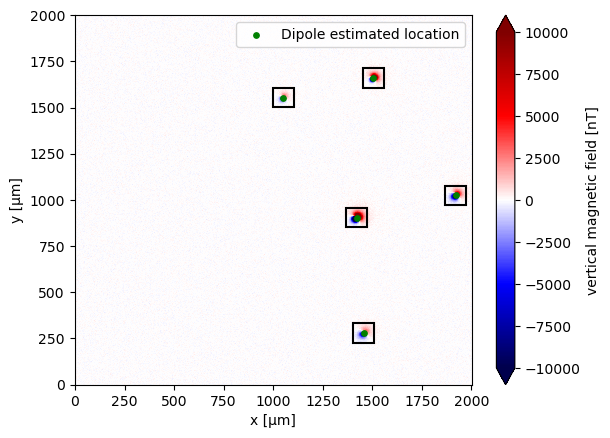

In [13]:
import verde as vd

SEED = 42
rng = np.random.default_rng(SEED)

sensor_sample_distance = 5.0
region = [0, 2000, 0, 2000]
spacing = 2.0
true_inclination = 30
true_declination = 40
true_dispersion_angle = 5
size = 5

directions_inclination, directions_declination = mg.random_directions(
    true_inclination,
    true_declination,
    true_dispersion_angle,
    size=size,
    random_state=SEED,
)

dipoles_amplitude = abs(rng.normal(0, 100, size)) * 1.0e-14
dipole_coordinates = (
    rng.integers(30, 1970, size),
    rng.integers(30, 1970, size),
    rng.integers(-20, -1, size),
)

dipole_moments = hm.magnetic_angles_to_vec(
    inclination=directions_inclination,
    declination=directions_declination,
    intensity=dipoles_amplitude,
)

data = mg.dipole_bz_grid(
    region, spacing, sensor_sample_distance, dipole_coordinates, dipole_moments
)
noise_std_dev = 100
data.values += rng.normal(loc=0, scale=noise_std_dev, size=data.shape)


height_difference = 5.0

data_up = (
    hm.upward_continuation(data, height_difference)
    .assign_attrs(data.attrs)
    .assign_coords(x=data.x, y=data.y)
    .assign_coords(z=data.z + height_difference)
    .rename("bz")
)

dx, dy, dz, tga = mg.gradient(data_up)
data_up["dx"], data_up["dy"], data_up["dz"], data_up["tga"] = dx, dy, dz, tga

stretched = skimage.exposure.rescale_intensity(
    tga, in_range=tuple(np.percentile(tga, (1, 99)))
)
data_tga_stretched = xr.DataArray(stretched, coords=data_up.coords)

bounding_boxes = mg.detect_anomalies(
    data_tga_stretched,
    size_range=[50, 150],
    detection_threshold=0.2,
    border_exclusion=2,
    size_multiplier=0.75,
)

data_updated, locations_, dipole_moments_, r2_values = (
    new_iterative_nonlinear_inversion(
        data_up,
        bounding_boxes,
        height_difference=height_difference,
        copy_data=True,
    )
)

fig, ax = plt.subplots()
data.plot.pcolormesh(ax=ax, cmap="seismic", vmin=-10000, vmax=10000)
mg.plot_bounding_boxes(bounding_boxes, ax=ax, color="black", linewidth=1.5)
locations_arr = np.array(locations_)
ax.scatter(
    locations_arr[:, 0],  # x
    locations_arr[:, 1],  # y
    c="green",
    marker=".",
    s=60,
    label="Dipole estimated location",
)
plt.legend()
plt.show()

In [14]:
r2_values

[np.float64(0.9999730958816975),
 np.float64(0.9996284270914166),
 np.float64(0.9999560412990196),
 np.float64(0.9999847218985637),
 np.float64(0.9999209015367573)]

In [15]:
dipole_coordinates

(array([1051, 1922, 1457, 1506, 1421]),
 array([1554, 1025,  278, 1659,  903]),
 array([-11, -13, -17,  -3,  -6]))

In [16]:
true_locations = []
for i in range(len(dipole_coordinates[0])):
    # print(i)
    true_locations.append(
        [
            np.array(
                [
                    dipole_coordinates[0][i],
                    dipole_coordinates[1][i],
                    dipole_coordinates[2][i],
                ]
            )
        ]
    )

true_locations

[[array([1051, 1554,  -11])],
 [array([1922, 1025,  -13])],
 [array([1457,  278,  -17])],
 [array([1506, 1659,   -3])],
 [array([1421,  903,   -6])]]

In [17]:
locations_

[array([1506.00093989, 1658.99927984,   -2.93782875]),
 array([1420.99713896,  903.00202157,   -5.69343044]),
 array([1456.97031152,  277.9908772 ,  -16.92688973]),
 array([1922.00116859, 1024.99454032,  -12.97101842]),
 array([1051.01688154, 1553.9998986 ,  -10.96039282])]

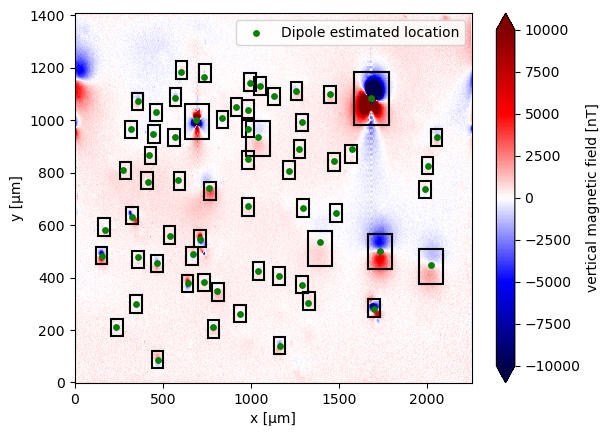

In [18]:
import ensaio
import harmonica as hm
import matplotlib.pyplot as plt
import numpy as np
import skimage.exposure
import xarray as xr

import magali as mg

fname = ensaio.fetch_morroco_speleothem_qdm(version=1, file_format="matlab")
data = mg.read_qdm_harvard(fname)

height_difference = 5.0

data_up = (
    hm.upward_continuation(data, height_difference)
    .assign_attrs(data.attrs)
    .assign_coords(x=data.x, y=data.y)
    .assign_coords(z=data.z + height_difference)
    .rename("bz")
)

dx, dy, dz, tga = mg.gradient(data_up)
data_up["dx"], data_up["dy"], data_up["dz"], data_up["tga"] = dx, dy, dz, tga

stretched = skimage.exposure.rescale_intensity(
    tga, in_range=tuple(np.percentile(tga, (1, 99)))
)
data_tga_stretched = xr.DataArray(stretched, coords=data_up.coords)

bounding_boxes = mg.detect_anomalies(
    data_tga_stretched,
    size_range=[20, 200],
    detection_threshold=0.015,
    border_exclusion=30,
)

data_updated, locations_, dipole_moments_, r2_values = (
    new_iterative_nonlinear_inversion(
        data_up,
        bounding_boxes,
        height_difference=height_difference,
        copy_data=True,
    )
)

fig, ax = plt.subplots()
data.plot.pcolormesh(ax=ax, cmap="seismic", vmin=-10000, vmax=10000)
mg.plot_bounding_boxes(bounding_boxes, ax=ax, color="black", linewidth=1.5)
locations_arr = np.array(locations_)
ax.scatter(
    locations_arr[:, 0],  # x
    locations_arr[:, 1],  # y
    c="green",
    marker=".",
    s=60,
    label="Dipole estimated location",
)
plt.legend()
plt.show()

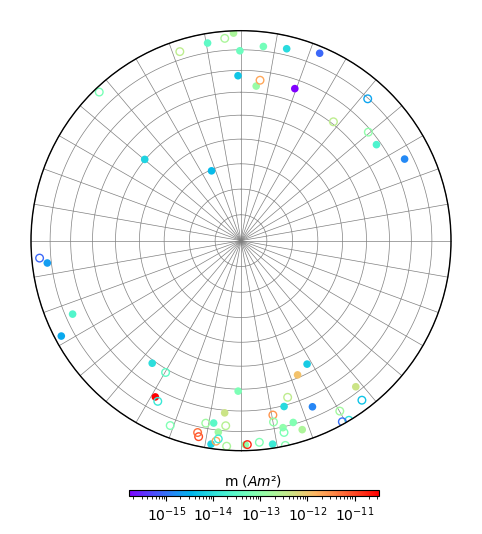

In [19]:
projection = StereographicProjection(dipole_moments_)

import matplotlib.patches

cmap = "rainbow"  # Escolha um colormap
cmap_norm = matplotlib.colors.LogNorm  # Normalize
maximum = np.max([len(inclinations)])
kwargs = dict(s=30, cmap=cmap, cmap_norm=cmap_norm)

fig, ax = plt.subplots(figsize=(10, 6))
tmp = projection.plot(ax=ax, add_ticks=False, **kwargs)

clb = fig.colorbar(
    tmp,
    ax=ax,
    # cax=fig.add_axes([0.5, 0.3, 0.25, 0.01]),
    cax=fig.add_axes([0.4, 0.07, 0.25, 0.01]),
    # format="%.0g",
    orientation="horizontal",
)
clb.set_label(label=r"m ($Am²$)", fontsize=10, labelpad=-37, loc="center")
clb.ax.tick_params(labelsize=10)

In [20]:
r2_values, len(bounding_boxes)

([np.float64(0.8889881605278364),
  np.float64(0.9961370945246228),
  np.float64(0.9200314554166201),
  np.float64(0.8419149850879772),
  np.float64(0.987772003578891),
  np.float64(0.9979099429530804),
  np.float64(0.9992404007303475),
  np.float64(0.8003171941006865),
  np.float64(0.9867502008210822),
  np.float64(0.9935143585248867),
  np.float64(0.9977724139944542),
  np.float64(0.985743540882233),
  np.float64(0.9971178665578591),
  np.float64(0.9901264105122458),
  np.float64(0.974527510802881),
  np.float64(0.9626963209613126),
  np.float64(0.9914470479286998),
  np.float64(0.9881353567812705),
  np.float64(0.9190810545431907),
  np.float64(0.8911169005936118),
  np.float64(0.9992343087191998),
  np.float64(0.9630730614058879),
  np.float64(0.9779956668859502),
  np.float64(0.8796771061962747),
  np.float64(0.858177676348383),
  np.float64(0.23442995446777837),
  np.float64(0.9884885304543782),
  np.float64(0.9526086883361471),
  np.float64(0.9193297881943976),
  np.float64(0.91

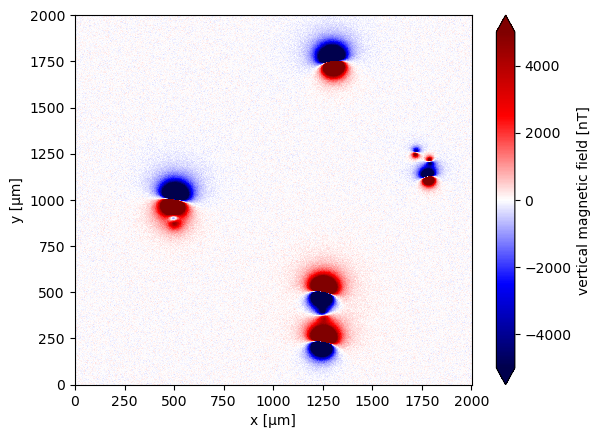

In [212]:
import numpy as np
import verde as vd
import magali as mg
import harmonica as hm

sensor_sample_distance = 5.0
region = [0, 2000, 0, 2000]
spacing = 2  

true_inclination = 30  
true_declination = 40  
true_dispersion_angle = 5  

directions_inclination, directions_declination = mg.random_directions(
    true_inclination,
    true_declination,
    true_dispersion_angle,
    size=size,
    random_state=5,
)

dipole_coordinates = (500, 500, -15) 

dipoles_amplitude = abs(np.random.normal(0, 100, size)) * 1.0e-14

dipole_coordinates = (
    np.concatenate([[1250, 1300, 500, 500, 1252, 1250, 1790, 1782, 1720]]),  
    np.concatenate([[500, 1750, 1000, 890, 380, 230, 1210, 1122, 1255]]),  
    np.concatenate([[-15, -15, -30, -30, -30, -15, -15, -15, -15]]),     
)

true_inclination = np.concatenate([[10, -10, -5, 10, 10, 10, -10, -160, -10]])
true_declination = np.concatenate([[10, 170, 190, 170, 170, 10, -10, -10, -170]])
true_intensity = np.concatenate([[5e-11, 5e-11, 5e-11, 2e-12, 2e-12, 5e-11, 5e-13, 5e-12, 5e-13 ]])

dipole_moments = hm.magnetic_angles_to_vec(
    inclination= true_inclination,
    declination= true_declination,
    intensity= true_intensity,
)
data = mg.dipole_bz_grid(
    region, spacing, sensor_sample_distance,
    dipole_coordinates, dipole_moments
)
noise_std_dev = 100
data.values += rng.normal(loc=0, scale=noise_std_dev, size=data.shape)

data.plot.pcolormesh(cmap="seismic", vmin=-5000, vmax=5000)

In [213]:
dipole_coordinates

(array([1250, 1300,  500,  500, 1252, 1250, 1790, 1782, 1720]),
 array([ 500, 1750, 1000,  890,  380,  230, 1210, 1122, 1255]),
 array([-15, -15, -30, -30, -30, -15, -15, -15, -15]))

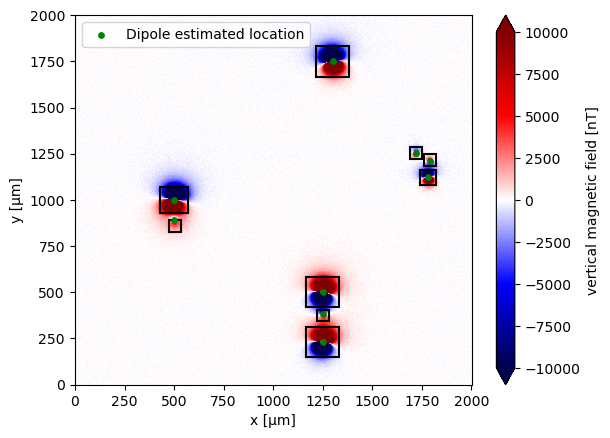

In [223]:
height_difference = 5.0

data_up = (
    hm.upward_continuation(data, height_difference)
    .assign_attrs(data.attrs)
    .assign_coords(x=data.x, y=data.y)
    .assign_coords(z=data.z + height_difference)
    .rename("bz")
)

dx, dy, dz, tga = mg.gradient(data_up)
data_up["dx"], data_up["dy"], data_up["dz"], data_up["tga"] = dx, dy, dz, tga

stretched = skimage.exposure.rescale_intensity(
    tga, in_range=tuple(np.percentile(tga, (1, 99)))
)
data_tga_stretched = xr.DataArray(stretched, coords=data_up.coords)

bounding_boxes = mg.detect_anomalies(
    data_tga_stretched,
    size_range=[20, 80],
    detection_threshold=0.015,
    border_exclusion=30,
    size_multiplier=1.1,
    overlap_ratio=0.9
)

data_updated, locations_, dipole_moments_, r2_values = (
    new_iterative_nonlinear_inversion(
        data_up,
        bounding_boxes,
        height_difference=height_difference,
        copy_data=True,
    )
)

fig, ax = plt.subplots()
data.plot.pcolormesh(ax=ax, cmap="seismic", vmin=-10000, vmax=10000)
mg.plot_bounding_boxes(bounding_boxes, ax=ax, color="black", linewidth=1.5)
locations_arr = np.array(locations_)
ax.scatter(
    locations_arr[:, 0],  # x
    locations_arr[:, 1],  # y
    c="green",
    marker=".",
    s=60,
    label="Dipole estimated location",
)
plt.legend()
plt.show()

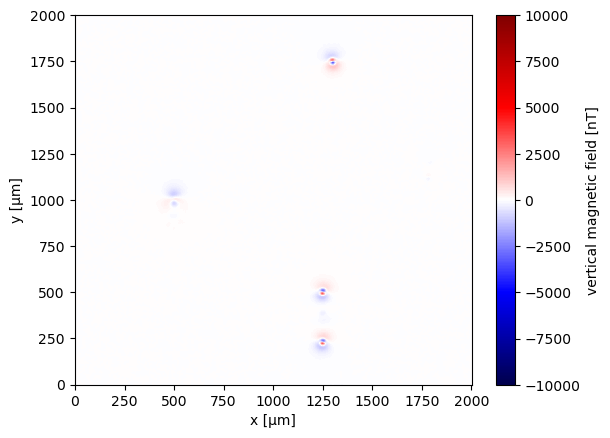

In [224]:
data_updated.plot.pcolormesh(cmap="seismic", vmin=-10000, vmax=10000)

In [225]:
r2_values

[np.float64(0.9999403056583116),
 np.float64(0.9999355980563154),
 np.float64(0.9999069714226083),
 np.float64(0.9998043465503061),
 np.float64(0.9999540922824746),
 np.float64(0.9990461096146834),
 np.float64(0.9994363588093153),
 np.float64(0.9981531066700852),
 np.float64(0.9996000151819882)]

In [226]:
len(locations_)

9

In [227]:
len(dipole_coordinates[0])

9

In [228]:
import numpy as np
import scipy.spatial as sps

dipole_coords_arr = np.column_stack(dipole_coordinates)
locations_arr = np.asarray(locations_)

locations_arr = locations_arr.reshape(-1, 3)

tree = sps.KDTree(dipole_coords_arr)
distances, indices = tree.query(locations_arr)

closest_true_points = dipole_coords_arr[indices]

print(indices)
print(distances)
print(closest_true_points)


[1 5 0 2 7 8 6 4 3]
[0.19323116 0.19202992 0.18985353 0.39060734 0.0611124  0.20047306
 0.53970437 2.18877491 1.1218721 ]
[[1300 1750  -15]
 [1250  230  -15]
 [1250  500  -15]
 [ 500 1000  -30]
 [1782 1122  -15]
 [1720 1255  -15]
 [1790 1210  -15]
 [1252  380  -30]
 [ 500  890  -30]]


In [229]:
r2_values

[np.float64(0.9999403056583116),
 np.float64(0.9999355980563154),
 np.float64(0.9999069714226083),
 np.float64(0.9998043465503061),
 np.float64(0.9999540922824746),
 np.float64(0.9990461096146834),
 np.float64(0.9994363588093153),
 np.float64(0.9981531066700852),
 np.float64(0.9996000151819882)]

In [236]:
any(x > 3 for x in distances)

False

In [237]:
any(r2 < 0.9 for r2 in r2_values)


False